In [1]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: /workspaces/TFMDS


In [2]:
# IMPORTS BÁSICOS
import os, sys
import pandas as pd
import numpy as np
import time

# Frameworks de deep learning y NeuralForecast
import torch
import pytorch_lightning as pl
from neuralforecast import NeuralForecast, __version__ as nf_version
# Importar GRU directamente (disponible en la versión instalada)
from neuralforecast.models import GRU
from neuralforecast.losses.pytorch import MAE

# Importar utilidades del repo (mismos helpers que en el cuaderno LSTM)
lib_dir = os.path.join(os.getcwd(), 'lib')
if lib_dir not in sys.path:
    sys.path.insert(0, lib_dir)

from lib.dl_utils import preparar_datos_neuralforecast, preparar_variables_estaticas
from lib.metricas import calcular_metricas, resumen_metricas
from lib.graficos_dl import grafico_prediccion_diaria_agregada, grafico_prediccion_por_cluster, grafico_productos_por_cluster, dashboard_metricas_dl

print(f"torch: {torch.__version__}")
print(f"pytorch_lightning: {pl.__version__}")
print(f"neuralforecast: {nf_version}")
print("GRU disponible en neuralforecast.models: ", GRU is not None)


torch: 2.9.1+cu128
pytorch_lightning: 2.6.0
neuralforecast: 3.1.2
GRU disponible en neuralforecast.models:  True


In [3]:
# LECTURA DE DATOS (usar los datos ya preparados en /workspaces/TFMDS/datos)
df_train_raw = pd.read_csv('datos/df_train_dl.csv', sep=';', parse_dates=['idSecuencia'])
df_test_raw = pd.read_csv('datos/df_test_dl.csv', sep=';', parse_dates=['idSecuencia'])
print(f"Datos cargados. Train: {df_train_raw.shape}, Test: {df_test_raw.shape}")

Datos cargados. Train: (625800, 27), Test: (27714, 27)


In [4]:
# PREPARAR DATOS PARA NEURALFORECAST
df_train_nf, df_test_nf = preparar_datos_neuralforecast(df_train_raw, df_test_raw, col_fecha='idSecuencia', col_producto='producto', col_target='udsVenta')
# Preparar variables estáticas (si aplica)
df_train_nf, df_test_nf, static_df = preparar_variables_estaticas(df_train_nf, df_test_nf, stat_exog_list=['Cluster_0','Cluster_1','Cluster_2','Cluster_3'])
print(f"Formatos NF: train {df_train_nf.shape}, test {df_test_nf.shape}")


✅ Variables estáticas extraídas:
   Columnas estáticas: ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Shape static_df: (894, 5)
   Productos únicos: 894

📊 Datasets temporales actualizados:
   Train: (625800, 23) (eliminadas 4 columnas)
   Test:  (27714, 23) (eliminadas 4 columnas)
Formatos NF: train (625800, 23), test (27714, 23)


In [5]:
# =============================================================================
# LIMPIEZA DE FEATURES HISTÓRICAS (evitar NaN al inicio del test)
# =============================================================================

print("\n" + "="*100)
print("🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)")
print("="*100)

# Definir la lista de features históricas que usa el modelo
hist_exog_list = [
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'media_mes_anterior',
    'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

# Comprobar existencia de columnas
def _check_missing(df, cols):
    return [c for c in cols if c not in df.columns]

missing_train = _check_missing(df_train_nf, hist_exog_list)
missing_test = _check_missing(df_test_nf, hist_exog_list)

if missing_train:
    print(f"⚠️ Faltan columnas en train: {missing_train}")
if missing_test:
    print(f"⚠️ Faltan columnas en test: {missing_test}")

cols_ok = [c for c in hist_exog_list if c in df_train_nf.columns and c in df_test_nf.columns]

if cols_ok:
    # Estadísticas antes
    na_train_before = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_before = int(df_test_nf[cols_ok].isna().sum().sum())

    # Forward fill por serie (unique_id) y rellenar remanentes al inicio con 0
    df_train_nf[cols_ok] = (
        df_train_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )
    df_test_nf[cols_ok] = (
        df_test_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )

    # Asegurar tipos numéricos (por si hubiera strings)
    for df_tmp in (df_train_nf, df_test_nf):
        for c in cols_ok:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors='coerce').fillna(0)

    # Estadísticas después
    na_train_after = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_after = int(df_test_nf[cols_ok].isna().sum().sum())

    print(f"✅ NaNs en train: {na_train_before} → {na_train_after}")
    print(f"✅ NaNs en test:  {na_test_before} → {na_test_after}")
else:
    print("⚠️ No hay columnas históricas válidas para limpiar.")

# Comprobación de contexto mínimo: filas previas por producto
min_hist = (
    df_train_nf.groupby('unique_id', observed=True)['ds']
    .count()
    .min()
)
print(f"ℹ️ Mínimo historial por producto en train: {min_hist} filas")
print("   Si es < input_size, considera reducir input_size o filtrar productos.")


🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)
✅ NaNs en train: 4 → 0
✅ NaNs en test:  0 → 0
ℹ️ Mínimo historial por producto en train: 700 filas
   Si es < input_size, considera reducir input_size o filtrar productos.
✅ NaNs en train: 4 → 0
✅ NaNs en test:  0 → 0
ℹ️ Mínimo historial por producto en train: 700 filas
   Si es < input_size, considera reducir input_size o filtrar productos.


In [6]:
# CONFIGURACIÓN DEL MODELO GRU (ajusta hiperparámetros según necesidades)
HORIZON = 30
modelo_gru = GRU(
    h=HORIZON,
    input_size=60,
    loss=MAE(),
    max_steps=1500,
    encoder_hidden_size=128,
    encoder_n_layers=2,
    decoder_hidden_size=128,
    decoder_layers=2,
    learning_rate=1e-3,
    scaler_type='standard',
    batch_size=32,
    random_seed=42,
    futr_exog_list=[ 'bolOpen', 'bolHoliday', 'bolPromocion', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos' ],
    hist_exog_list=[ 'lag_ventas_1','lag_ventas_2','lag_ventas_3','lag_ventas_4' ],
    stat_exog_list=['Cluster_0','Cluster_1','Cluster_2','Cluster_3'],
    enable_progress_bar=True
)
print('Modelo GRU configurado: ', modelo_gru)

Seed set to 42


Modelo GRU configurado:  GRU


In [7]:
# ENTRENAMIENTO
nf = NeuralForecast(models=[modelo_gru], freq='D')
print('Entrenando...')
start = time.perf_counter()
nf.fit(df=df_train_nf, static_df=static_df)
print(f'Entrenamiento completado en {time.perf_counter()-start:.2f}s')

Entrenando...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | hist_encoder | GRU           | 155 K  | train | 0    
4 | mlp_decoder  | MLP           | 17.5 K | train | 0    
---------------------------------------------------------------
172 K     Trainable params
0         Non-trainable params
172 K     Total params
0.691     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Total Flops

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=3000` reached.


Entrenamiento completado en 781.13s


In [8]:
# PREDICCIÓN
y_hat = nf.predict(futr_df=df_test_nf)
print('Predicciones generadas. Shape:', getattr(y_hat, 'shape', None))

/home/vscode/.local/lib/python3.10/site-packages/neuralforecast/core.py:948: UserWarning: Dropped 894 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicciones generadas. Shape: (26820, 3)


In [9]:
# RECONSTRUIR Y CALCULAR MÉTRICAS (misma lógica que en LSTM)
if y_hat.index.name == 'unique_id':
    y_hat = y_hat.reset_index()
# rename if needed and merge with df_test_nf
if 'GRU' in y_hat.columns:
    y_hat = y_hat.rename(columns={'GRU':'prediccion'})
elif 'prediccion' not in y_hat.columns:
    pred_cols = [c for c in y_hat.columns if c not in ['unique_id','ds']]
    if pred_cols:
        y_hat = y_hat.rename(columns={pred_cols[0]:'prediccion'})
df_test_pred = df_test_nf[['unique_id','ds','y']].merge(y_hat[['unique_id','ds','prediccion']], on=['unique_id','ds'], how='left')
df_test_pred['idSecuencia']=df_test_pred['ds']
df_test_pred['producto']=df_test_pred['unique_id']
df_test_pred['udsVenta']=df_test_pred['y']
df_test_pred['prediccion'] = df_test_pred['prediccion'].clip(lower=0)
df_test_pred['error'] = df_test_pred['prediccion'] - df_test_pred['udsVenta']
df_test_pred['error_abs'] = np.abs(df_test_pred['error'])
print('Dataset de predicciones preparado:', df_test_pred.shape)

Dataset de predicciones preparado: (27714, 9)


In [10]:
# ============================================================================
# RECONSTRUIR COLUMNA CLUSTER DESDE static_df (one-hot estático)
# ============================================================================

# Si ya existe 'Cluster' en el dataset de predicciones, la respetamos
if 'Cluster' in df_test_pred.columns:
    try:
        df_test_pred['Cluster'] = df_test_pred['Cluster'].astype('Int64')
    except Exception:
        pass
    print("\n✅ Columna 'Cluster' ya presente en df_test_pred.")
    print("   Distribución:")
    print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
else:
    # Intentar reconstruir desde static_df (variables estáticas por unique_id)
    cluster_cols = [c for c in static_df.columns if c.startswith('Cluster_')]

    if cluster_cols:
        # Ordenar columnas y calcular argmax por unique_id
        cluster_cols = sorted(cluster_cols, key=lambda x: int(x.split('_')[1]))
        static_map = static_df[['unique_id'] + cluster_cols].copy()
        cluster_idx = static_map[cluster_cols].to_numpy().argmax(axis=1)
        static_map['Cluster'] = cluster_idx

        # Unir al dataset de predicciones
        df_test_pred = df_test_pred.merge(
            static_map[['unique_id', 'Cluster']],
            on='unique_id',
            how='left',
        )

        print(f"\n✅ 'Cluster' reconstruido desde static_df ({len(cluster_cols)} columnas one-hot).")
        print("   Distribución:")
        print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
    else:
        print("\n⚠️ No se encontraron columnas 'Cluster_*' en static_df.")
        print("   Las visualizaciones por cluster no estarán disponibles.")


✅ 'Cluster' reconstruido desde static_df (4 columnas one-hot).
   Distribución:
Cluster
0     9331
1     3286
2      496
3    14601
Name: count, dtype: int64


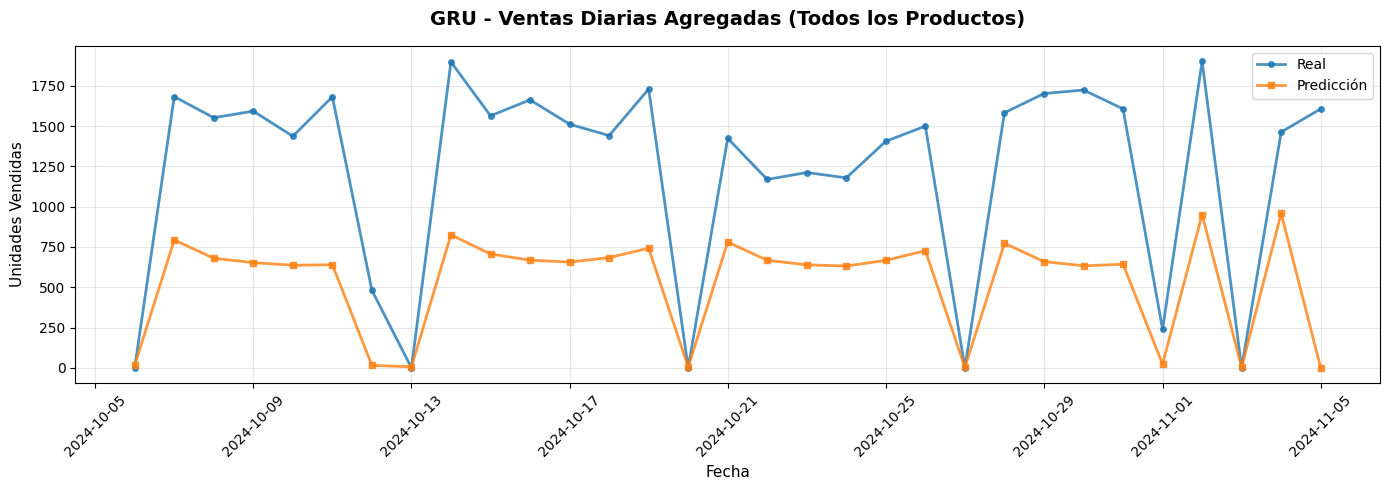


📊 Estadísticas diarias agregadas:
   MAE diario:  694.70
   RMSE diario: 795.73
   Error % medio: inf%


In [11]:
grafico_prediccion_diaria_agregada(
    df=df_test_pred,
    col_fecha='idSecuencia',
    col_real='udsVenta',
    col_pred='prediccion',
    titulo='GRU - Ventas Diarias Agregadas (Todos los Productos)',
    figsize=(14, 5)
)

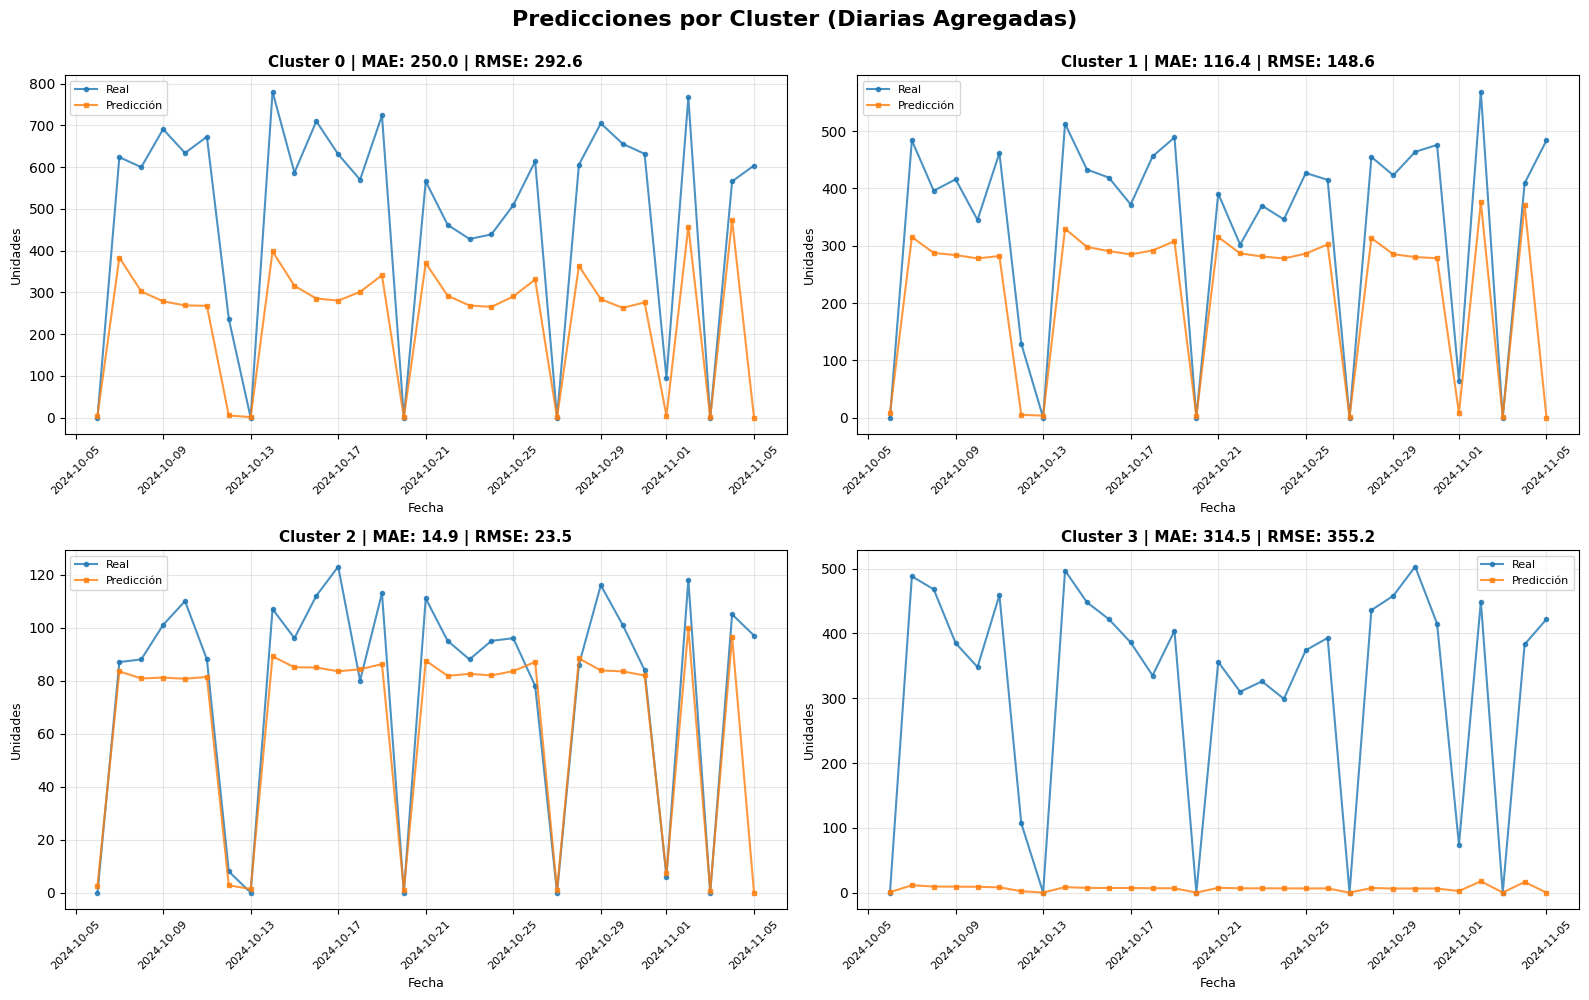

In [12]:
grafico_prediccion_por_cluster(
    df=df_test_pred,
    col_cluster='Cluster',
    col_fecha='idSecuencia',
    col_real='udsVenta',
    col_pred='prediccion',
    figsize=(16, 10)
)

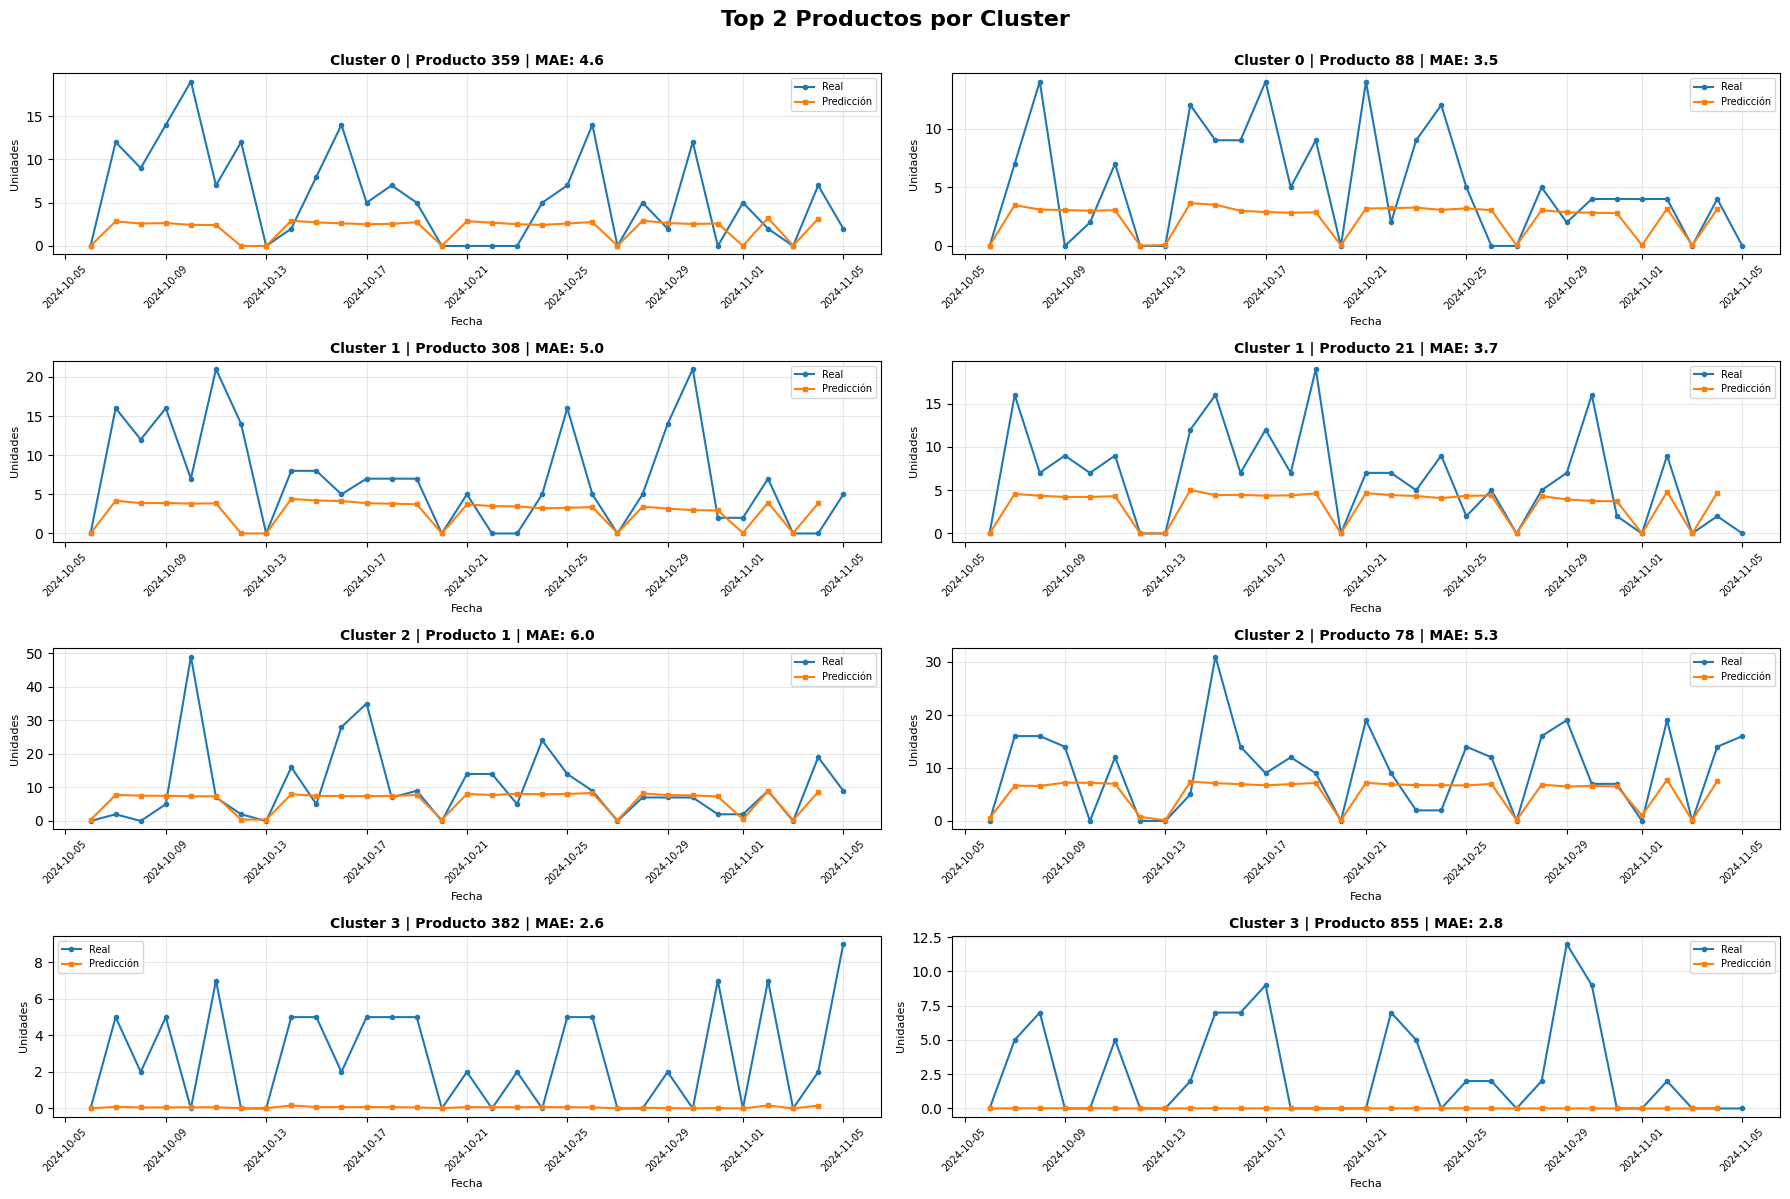

In [13]:
grafico_productos_por_cluster(
    df=df_test_pred,
    col_cluster='Cluster',
    col_producto='producto',
    col_fecha='idSecuencia',
    col_real='udsVenta',
    col_pred='prediccion',
    n_productos_por_cluster=2,
    figsize=(18, 12)
)


📊 CÁLCULO DE MÉTRICAS - GRU

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
                 GRU 1.1624 5.6311 2.373 0.1657     71.26     154.41 0.7333    85.77

🏆 Mejor modelo: GRU (RMSE: 2.3730)


/workspaces/TFMDS/lib/graficos_dl.py:314: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


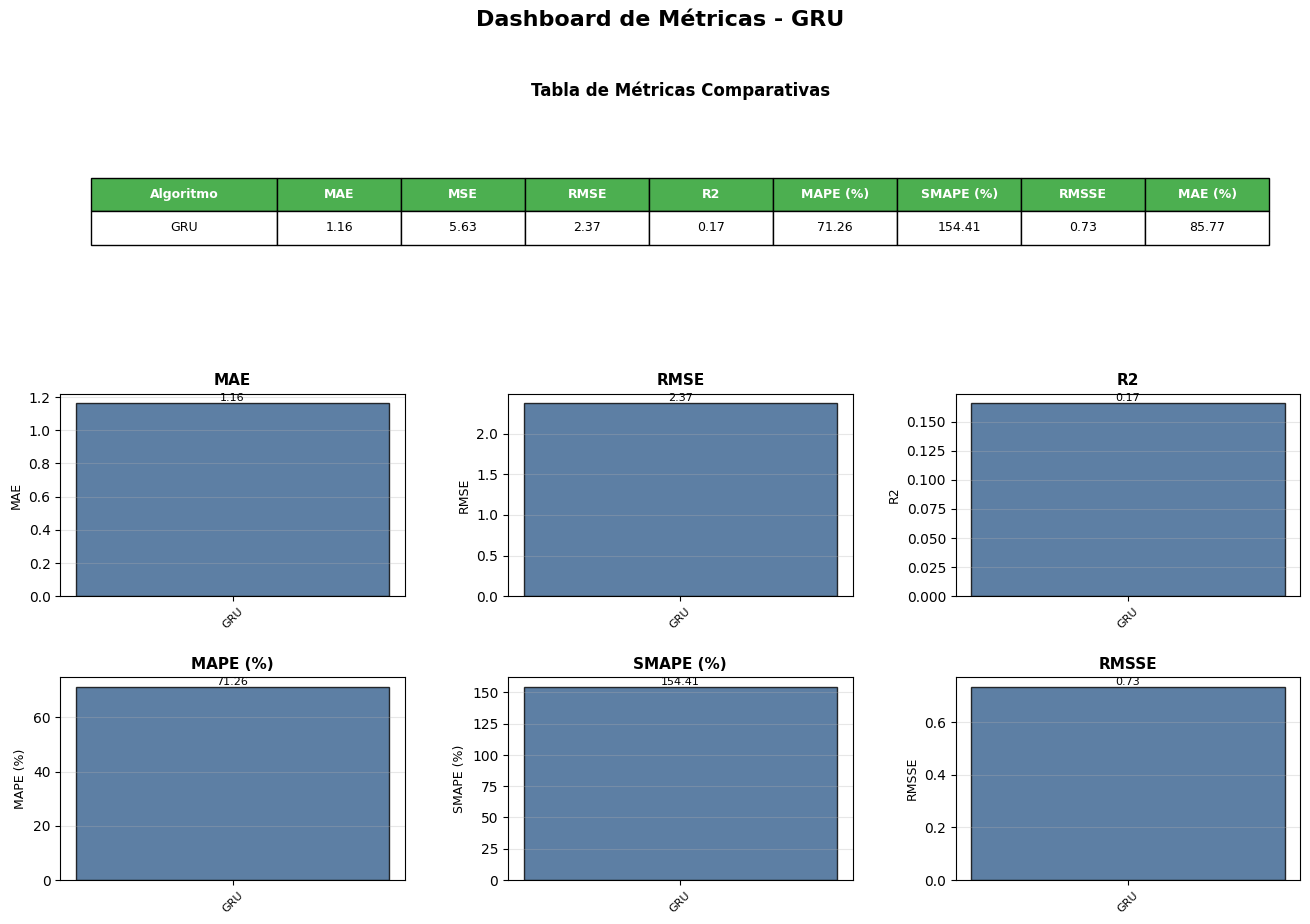

In [14]:
# ============================================================================
# CÁLCULO DE MÉTRICAS - GRU
# ============================================================================

print("\n" + "="*100)
print("📊 CÁLCULO DE MÉTRICAS - GRU")
print("="*100)

# Filtrar valores válidos (sin NaN)
df_valid = df_test_pred.dropna(subset=['prediccion', 'udsVenta'])

# Calcular métricas
metricas_gru = calcular_metricas(
    y=df_valid['udsVenta'],
    y_pred=df_valid['prediccion'],
    name='GRU'
)

# Mostrar resumen
resumen_metricas([metricas_gru])

# Guardar para comparación posterior
todas_metricas = [metricas_gru]

# Preparar diccionario de métricas para el dashboard
# La función espera: {'nombre_algoritmo': {'MAE': x, 'RMSE': y, ...}, ...}
metricas_dict = {}
for m in todas_metricas:
    nombre_algoritmo = m['Algoritmo']
    # Copiar todas las métricas excepto 'Algoritmo'
    metricas_dict[nombre_algoritmo] = {k: v for k, v in m.items() if k != 'Algoritmo'}

dashboard_metricas_dl(
    metricas_dict=metricas_dict,
    titulo='Dashboard de Métricas - GRU',
    figsize=(16, 10)
)

In [15]:
# ============================================================================
# GUARDAR RESULTADOS DE MÉTRICAS - GRU
# ============================================================================

print("\n" + "="*100)
print("💾 GUARDANDO RESULTADOS - GRU")
print("="*100)

# Convertir lista de métricas a DataFrame
df_resultados = pd.DataFrame(todas_metricas)

# Guardar en CSV
output_path = 'datos/resultados_metricas_gru.csv'
df_resultados.to_csv(output_path, index=False)

print(f"\n✅ Métricas guardadas en: {output_path}")
print(f"   Columnas: {list(df_resultados.columns)}")
print("\n📊 Resumen de resultados:")
print(df_resultados.to_string(index=False))
print("="*100)


💾 GUARDANDO RESULTADOS - GRU

✅ Métricas guardadas en: datos/resultados_metricas_gru.csv
   Columnas: ['Algoritmo', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)', 'RMSSE', 'MAE (%)']

📊 Resumen de resultados:
Algoritmo    MAE    MSE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
      GRU 1.1624 5.6311 2.373 0.1657     71.26     154.41 0.7333    85.77
